# T001 · 化合物数据获取 (ChEMBL)

**注意：** 本教程是 TeachOpenCADD 的一部分，该平台旨在教授特定领域技能，并为研究项目提供管道模板作为起点。

作者：

- Svetlana Leng, CADD seminar 2017, Volkamer lab, Charité/FU Berlin 
- Paula Junge, CADD seminar 2018, Volkamer lab, Charité/FU Berlin
- Dominique Sydow, 2019-2020, [Volkamer lab, Charité](https://volkamerlab.org/)
- Andrea Volkamer, 2020, [Volkamer lab, Charité](https://volkamerlab.org/)
- Yonghui Chen, 2020, [Volkamer lab, Charité](https://volkamerlab.org/)

__教程 T001__：本教程是 [首篇 TeachOpenCADD 论文](https://jcheminf.biomedcentral.com/articles/10.1186/s13321-019-0351-x) 中描述的 TeachOpenCADD 流程的一部分，包括 T001-T010 教程。

## 本教程目标

在本 notebook 中，我们将更多地了解 ChEMBL 数据库，以及如何从中提取数据，即针对感兴趣靶标的（化合物、活性数据）配对。这些数据集可用于许多化学信息学任务，如相似性搜索、聚类或机器学习。

我们的工作将包括查找针对特定靶标进行测试的化合物，并筛选可用的生物活性数据。

### 理论内容

* ChEMBL 数据库
    * ChEMBL Web 服务
    * ChEMBL Web 资源客户端
* 化合物活性度量
    * IC50 值
    * pIC50 值

### 实践内容
    
**目标：获取针对给定靶标的化合物生物活性数据列表**

* 连接 ChEMBL 数据库
* 获取靶标数据（示例：EGFR 激酶）
    * 获取并下载靶标数据
    * 选择靶标 ChEMBL ID
* 获取生物活性数据
    * 获取并下载靶标的生物活性数据
    * 预处理和筛选生物活性数据
* 获取化合物数据
    * 获取并下载化合物数据
    * 预处理和筛选化合物数据
* 输出生物活性-化合物数据
    * 合并生物活性和化合物数据，并添加 pIC50 值
    * 绘制 pIC50 最高的分子
    * 将生物活性数据冻结到 ChEMBL 27
    * 写入输出文件

### 参考文献

* ChEMBL 生物活性数据库：[Gaulton *et al.*, <i>Nucleic Acids Res.</i> (2017), 45(Database issue), D945–D954](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5210557/)
* ChEMBL Web 服务：[Davies *et al.*, <i>Nucleic Acids Res.</i> (2015), <b>43</b>, 612-620](https://academic.oup.com/nar/article/43/W1/W612/2467881) 
* [ChEMBL Web 界面](https://www.ebi.ac.uk/chembl/)
*  GitHub [ChEMBL Web 资源客户端](https://github.com/chembl/chembl_webresource_client)
* EBI RDF 平台：[Jupp *et al.*, <i>Bioinformatics </i> (2014), 30(9), 1338-9](https://www.ncbi.nlm.nih.gov/pubmed/24413672)
* 关于半数最大抑制浓度的信息：[(p)IC50](https://en.wikipedia.org/wiki/IC50)
* [UniProt 网站](https://www.uniprot.org/)

In [ ]:
import sys

if "google.colab" in sys.modules:
    %pip install teachopencadd --no-deps -q
    !teachopencadd -d 1
    %pip uninstall teachopencadd -y -q
    %pip install -qr requirements.txt

## 理论

### ChEMBL 数据库
>"ChEMBL 是一个人工维护的、具有类药性质的生物活性分子数据库。它汇集了化学、生物活性和基因组数据，以帮助将基因组信息转化为有效的新药。"（[ChEMBL 网站](https://www.ebi.ac.uk/chembl/)）

* 开放的大规模生物活性数据库
* **当前数据内容（截至 2020 年 9 月，ChEMBL 27）：**
    * 超过 190 万个不同化合物
    * 超过 1600 万个活性值
    * 实验映射到约 13,000 个靶标
* **数据来源**包括科学文献、PubChem 生物实验、被忽视疾病药物倡议（DNDi）、BindingDB 数据库等
* ChEMBL 数据可通过 [Web 界面](https://www.ebi.ac.uk/chembl/)、[EBI-RDF 平台](https://www.ncbi.nlm.nih.gov/pubmed/24413672) 和 [ChEMBL Web 资源客户端](https://github.com/chembl/chembl_webresource_client) 访问

#### ChEMBL Web 服务

* RESTful Web 服务
* ChEMBL Web 服务版本 2.x 资源模式：

<!---
![ChEMBL web service schema](images/chembl_webservices_schema_diagram.jpg)
--->
![ChEMBL web service schema](images/chembl_webservices_schema_diagram.jpg)

*图 1：*
"[ChEMBL Web 服务模式图](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC4489243/figure/F2/)。椭圆形代表 ChEMBL Web 服务资源，两个资源之间的连线表示它们共享一个公共属性。箭头方向显示可以找到资源类型主要信息的位置。虚线表示两个资源之间的关系行为不同。例如，`Image` 资源提供 `Molecule` 的图形化表示。"
图和说明取自：[<i>Nucleic Acids Res.</i> (2015), <b>43</b>, 612-620](https://academic.oup.com/nar/article/43/W1/W612/2467881)。

#### ChEMBL Web 资源客户端

* 用于访问 ChEMBL 数据的 Python 客户端库
* 处理与 HTTPS 协议的交互
* 结果的惰性求值 -> 减少网络请求数量

### 化合物活性度量

#### IC50 值

* [半数最大抑制浓度](https://en.wikipedia.org/wiki/IC50)
* 表示某种特定药物或其他物质需要多少才能抑制给定生物过程的一半

![ Wiki_Example_IC50_curve](images/Wiki_Example_IC50_curve_demonstrating_visually_how_IC50_is_derived.png)

*图 2：* IC50 值推导原理的可视化演示：
(i) 在 y 轴上绘制抑制数据，在 x 轴上绘制 log（浓度）。(ii) 确定最大抑制和最小抑制。(iii) IC50 是曲线通过 50% 抑制水平时的浓度。图 ["Example IC50 curve"](https://en.wikipedia.org/wiki/IC50#/media/File:Example_IC50_curve_demonstrating_visually_how_IC50_is_derived.png) 由 JesseAlanGordon 提供，根据 [CC BY-SA 3.0](https://creativecommons.org/licenses/by-sa/3.0/) 许可。

#### pIC50 值

* 为了便于比较 IC50 值（这些值范围很大且以不同单位表示，如 M、nM 等），通常使用 pIC50 值
* pIC50 是将 IC50 值转换为摩尔单位后的负对数：
    $ pIC_{50} = -log_{10}(IC_{50}) $，其中 $ IC_{50}$ 以 M 为单位
* 较高的 pIC50 值表示药物的效力呈指数级增强
* 注意，转换可以根据相应的 IC50 单位进行调整，例如对于 nM：$pIC_{50} = -log_{10}(IC_{50}*10^{-9})= 9-log_{10}(IC_{50}) $

其他活性度量：

除了 IC50 和 pIC50 之外，还使用其他生物活性度量，如平衡常数 [KI](https://en.wikipedia.org/wiki/Equilibrium_constant) 和半数最大效应浓度 [EC50](https://en.wikipedia.org/wiki/EC50)。

## 实践

接下来，我们想要下载所有针对我们感兴趣的靶标——**表皮生长因子受体**（[**EGFR**](https://www.uniprot.org/uniprot/P00533)）激酶——进行过测试的分子。

### 连接 ChEMBL 数据库

首先，导入 ChEMBL Web 资源客户端以及其他 Python 库。

In [2]:
import math
from pathlib import Path
from zipfile import ZipFile
from tempfile import TemporaryDirectory

import numpy as np
import pandas as pd
from rdkit.Chem import PandasTools
from chembl_webresource_client.new_client import new_client
from tqdm.auto import tqdm

/opt/miniconda3/envs/T001_3120/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
HERE = Path(_dh[-1])
DATA = HERE / "data"

接下来，我们创建用于 API 访问的资源对象。

In [4]:
targets_api = new_client.target
compounds_api = new_client.molecule
bioactivities_api = new_client.activity

In [5]:
type(targets_api)

chembl_webresource_client.query_set.QuerySet

### 获取靶标数据（EGFR 激酶）

* 从 [UniProt 网站](https://www.uniprot.org/) 获取感兴趣靶标的 UniProt ID（EGFR 激酶：[P00533](http://www.uniprot.org/uniprot/P00533)）
* 使用 UniProt ID 获取靶标信息

如果您对其他靶标感兴趣，可以选择不同的 UniProt ID。

In [6]:
uniprot_id = "P00533"

#### 获取靶标数据

In [7]:
# 从 ChEMBL 获取靶标信息，但限制为仅指定值
targets = targets_api.get(target_components__accession=uniprot_id).only(
    "target_chembl_id", "organism", "pref_name", "target_type"
)
print(f'The type of the targets is "{type(targets)}"')

The type of the targets is "<class 'chembl_webresource_client.query_set.QuerySet'>"


#### 下载靶标数据

查询结果存储在 `targets` 中，这是一个 `QuerySet`，即在我们要求之前不会从 ChEMBL 获取结果（这里使用 `pandas.DataFrame.from_records`）。

有关 `QuerySet` 数据类型的更多信息：

> QuerySet 是惰性的——创建 QuerySet 的行为不涉及任何数据库活动。您可以整天堆叠过滤器，在 QuerySet 被求值之前，Django 实际上不会运行查询。
([querysets-are-lazy](https://docs.djangoproject.com/en/3.0/topics/db/queries/#querysets-are-lazy))

In [8]:
targets = pd.DataFrame.from_records(targets)
targets

,organism,pref_name,target_chembl_id,target_type
0,Homo sapiens,Epidermal growth factor receptor,CHEMBL203,SINGLE PROTEIN
1,Homo sapiens,Epidermal growth factor receptor,CHEMBL203,SINGLE PROTEIN
2,Homo sapiens,Epidermal growth factor receptor and ErbB2 (HE...,CHEMBL2111431,PROTEIN FAMILY
3,Homo sapiens,Epidermal growth factor receptor,CHEMBL2363049,PROTEIN FAMILY
4,Homo sapiens,MER intracellular domain/EGFR extracellular do...,CHEMBL3137284,CHIMERIC PROTEIN
5,Homo sapiens,Protein cereblon/Epidermal growth factor receptor,CHEMBL4523680,PROTEIN-PROTEIN INTERACTION
6,Homo sapiens,EGFR/PPP1CA,CHEMBL4523747,PROTEIN-PROTEIN INTERACTION
7,Homo sapiens,von Hippel-Lindau disease tumor suppressor/EGFR,CHEMBL4523998,PROTEIN-PROTEIN INTERACTION
8,Homo sapiens,Baculoviral IAP repeat-containing protein 2/Ep...,CHEMBL4802031,PROTEIN-PROTEIN INTERACTION
9,Homo sapiens,CCN2-EGFR,CHEMBL5465557,PROTEIN-PROTEIN INTERACTION


#### 选择靶标（靶标 ChEMBL ID）

检查条目后，我们选择第一个条目作为我们感兴趣的靶标：

`CHEMBL203`：它是一个单一蛋白，代表人表皮生长因子受体（EGFR，也称为 erbB1）

In [9]:
target = targets.iloc[0]
target

organism                                Homo sapiens
pref_name           Epidermal growth factor receptor
target_chembl_id                           CHEMBL203
target_type                           SINGLE PROTEIN
Name: 0, dtype: object

保存选定的 ChEMBL ID。

In [10]:
chembl_id = target.target_chembl_id
print(f"The target ChEMBL ID is {chembl_id}")
# NBVAL_CHECK_OUTPUT

The target ChEMBL ID is CHEMBL203


### 获取生物活性数据

现在，我们要查询感兴趣靶标的生物活性数据。

#### 获取靶标的生物活性数据

在此步骤中，我们获取生物活性数据并过滤，仅考虑

* 人类蛋白，
* 生物活性类型 IC50，
* 精确测量值（关系符 `'='`），以及
* 结合数据（实验类型 `'B'`）。

In [11]:
bioactivities = bioactivities_api.filter(
    target_chembl_id=chembl_id, type="IC50", relation="=", assay_type="B"
).only(
    "activity_id",
    "assay_chembl_id",
    "assay_description",
    "assay_type",
    "molecule_chembl_id",
    "type",
    "standard_units",
    "relation",
    "standard_value",
    "target_chembl_id",
    "target_organism",
)

print(f"Length and type of bioactivities object: {len(bioactivities)}, {type(bioactivities)}")

Length and type of bioactivities object: 17107, <class 'chembl_webresource_client.query_set.QuerySet'>


我们生物活性集合中的每个条目都包含以下信息：

In [12]:
print(f"Length and type of first element: {len(bioactivities[0])}, {type(bioactivities[0])}")
bioactivities[0]

Length and type of first element: 13, <class 'dict'>


{'activity_id': 32260,
 'assay_chembl_id': 'CHEMBL674637',
 'assay_description': 'Inhibitory activity towards tyrosine phosphorylation for the epidermal growth factor-receptor kinase',
 'assay_type': 'B',
 'molecule_chembl_id': 'CHEMBL68920',
 'relation': '=',
 'standard_units': 'nM',
 'standard_value': '41.0',
 'target_chembl_id': 'CHEMBL203',
 'target_organism': 'Homo sapiens',
 'type': 'IC50',
 'units': 'uM',
 'value': '0.041'}

#### 从 ChEMBL 下载生物活性数据

最后，我们将 `QuerySet` 下载为 `pandas` `DataFrame`。

> **注意**：此步骤不应超过 2 分钟，如果超过，请尝试从*"获取靶标的生物活性数据"*开始重新运行所有单元格，或阅读以下信息：

<details>
    
<summary>加载本地版本的数据（如果在获取数据时遇到任何问题）</summary>
    
如果您在查询 ChEMBL 数据库时遇到困难，我们还提供了您将在下面单元格中构建的结果 DataFrame。如果您想使用已保存的版本，请改用以下代码来获取 `bioactivities_df`：
  
```python
# 将下面单元格中的第一行替换为这行
bioactivities_df = pd.read_csv(DATA / "EGFR_bioactivities_CHEMBL27.csv.zip", index_col=0)
```

</details>

In [13]:
bioactivities_df = pd.DataFrame.from_dict(bioactivities)
print(f"DataFrame shape: {bioactivities_df.shape}")
bioactivities_df.head()

DataFrame shape: (17107, 13)


,activity_id,assay_chembl_id,assay_description,assay_type,molecule_chembl_id,relation,standard_units,standard_value,target_chembl_id,target_organism,type,units,value
0,32260,CHEMBL674637,Inhibitory activity towards tyrosine phosphory...,B,CHEMBL68920,=,nM,41.0,CHEMBL203,Homo sapiens,IC50,uM,0.041
1,32267,CHEMBL674637,Inhibitory activity towards tyrosine phosphory...,B,CHEMBL69960,=,nM,170.0,CHEMBL203,Homo sapiens,IC50,uM,0.17
2,32680,CHEMBL677833,In vitro inhibition of Epidermal growth factor...,B,CHEMBL137635,=,nM,9300.0,CHEMBL203,Homo sapiens,IC50,uM,9.3
3,32770,CHEMBL674643,Inhibitory concentration of EGF dependent auto...,B,CHEMBL306988,=,nM,500000.0,CHEMBL203,Homo sapiens,IC50,uM,500.0
4,32772,CHEMBL674643,Inhibitory concentration of EGF dependent auto...,B,CHEMBL66879,=,nM,3000000.0,CHEMBL203,Homo sapiens,IC50,uM,3000.0


请注意，前两行描述的是同一条生物活性条目；我们将在稍后的去重步骤中删除此类重复。还要注意，我们有 `standard_units`/`units` 和 `standard_values`/`values` 列；在接下来的步骤中，我们将使用标准化列（由 ChEMBL 标准化），因此我们删除另外两列。

如果我们使用 `units` 和 `values` 列，我们可能需要将许多不同单位的值都转换为 nM：

In [14]:
bioactivities_df["units"].unique()

array(['uM', 'nM', 'pM', 'M', "10'3 uM", "10'1 ug/ml", 'ug ml-1',
       "10'-1microM", "10'1 uM", "10'-1 ug/ml", "10'-2 ug/ml", "10'2 uM",
       "10'-3 ug/ml", "10'-2microM", '/uM', "10'-6g/ml", 'mM', 'umol/L',
       'nmol/L', "10'-10M", "10'-7M", 'nmol', '10^-8M', '10^3 uM'],
      dtype=object)

In [15]:
bioactivities_df.drop(["units", "value"], axis=1, inplace=True)
bioactivities_df.head()

,activity_id,assay_chembl_id,assay_description,assay_type,molecule_chembl_id,relation,standard_units,standard_value,target_chembl_id,target_organism,type
0,32260,CHEMBL674637,Inhibitory activity towards tyrosine phosphory...,B,CHEMBL68920,=,nM,41.0,CHEMBL203,Homo sapiens,IC50
1,32267,CHEMBL674637,Inhibitory activity towards tyrosine phosphory...,B,CHEMBL69960,=,nM,170.0,CHEMBL203,Homo sapiens,IC50
2,32680,CHEMBL677833,In vitro inhibition of Epidermal growth factor...,B,CHEMBL137635,=,nM,9300.0,CHEMBL203,Homo sapiens,IC50
3,32770,CHEMBL674643,Inhibitory concentration of EGF dependent auto...,B,CHEMBL306988,=,nM,500000.0,CHEMBL203,Homo sapiens,IC50
4,32772,CHEMBL674643,Inhibitory concentration of EGF dependent auto...,B,CHEMBL66879,=,nM,3000000.0,CHEMBL203,Homo sapiens,IC50


#### 预处理和筛选生物活性数据

1. 将 `standard_value` 的数据类型从 `object` 转换为 `float`
2. 删除有缺失值的条目
3. 仅保留 `standard_unit == nM` 的条目
4. 删除重复分子
5. 重置 `DataFrame` 索引
6. 重命名列

**1. 将 "standard_value" 的数据类型从 "object" 转换为 "float"**

字段 `standard_value` 保存标准化（此处为 IC50）值。为了使这些值在后续计算中可用，将值转换为浮点数。

In [16]:
bioactivities_df.dtypes

activity_id            int64
assay_chembl_id       object
assay_description     object
assay_type            object
molecule_chembl_id    object
relation              object
standard_units        object
standard_value        object
target_chembl_id      object
target_organism       object
type                  object
dtype: object

In [17]:
bioactivities_df = bioactivities_df.astype({"standard_value": "float64"})
bioactivities_df.dtypes

activity_id             int64
assay_chembl_id        object
assay_description      object
assay_type             object
molecule_chembl_id     object
relation               object
standard_units         object
standard_value        float64
target_chembl_id       object
target_organism        object
type                   object
dtype: object

**2. 删除有缺失值的条目**

使用参数 `inplace=True` 直接在当前 `DataFrame` 中删除值。

In [18]:
bioactivities_df.dropna(axis=0, how="any", inplace=True)
print(f"DataFrame shape: {bioactivities_df.shape}")

DataFrame shape: (17106, 11)


**3. 仅保留 "standard_unit == nM" 的条目**

我们只想保留 nM 单位的生物活性条目，因此删除所有其他单位的条目。

In [19]:
print(f"Units in downloaded data: {bioactivities_df['standard_units'].unique()}")
print(f"Number of non-nM entries:\
    {bioactivities_df[bioactivities_df['standard_units'] != 'nM'].shape[0]}")

Units in downloaded data: ['nM' 'ug.mL-1' '/uM' '10^3 uM']
Number of non-nM entries:    71


In [20]:
bioactivities_df = bioactivities_df[bioactivities_df["standard_units"] == "nM"]
print(f"Units after filtering: {bioactivities_df['standard_units'].unique()}")

Units after filtering: ['nM']


In [21]:
print(f"DataFrame shape: {bioactivities_df.shape}")

DataFrame shape: (17035, 11)


**4. 删除重复分子**

有时同一分子（`molecule_chembl_id`）被测试了多次，在这种情况下，我们仅保留第一个。

注意，其他选择可以是保留具有最佳值的那个，或者保留相应化合物所有实验结果的平均值。

In [22]:
bioactivities_df.drop_duplicates("molecule_chembl_id", keep="first", inplace=True)
print(f"DataFrame shape: {bioactivities_df.shape}")

DataFrame shape: (9996, 11)


**5. 重置 DataFrame 索引**

由于我们删除了一些行，但稍后需要遍历索引，因此我们重置索引使其连续。

In [23]:
bioactivities_df.reset_index(drop=True, inplace=True)
bioactivities_df.head()

,activity_id,assay_chembl_id,assay_description,assay_type,molecule_chembl_id,relation,standard_units,standard_value,target_chembl_id,target_organism,type
0,32260,CHEMBL674637,Inhibitory activity towards tyrosine phosphory...,B,CHEMBL68920,=,nM,41.0,CHEMBL203,Homo sapiens,IC50
1,32267,CHEMBL674637,Inhibitory activity towards tyrosine phosphory...,B,CHEMBL69960,=,nM,170.0,CHEMBL203,Homo sapiens,IC50
2,32680,CHEMBL677833,In vitro inhibition of Epidermal growth factor...,B,CHEMBL137635,=,nM,9300.0,CHEMBL203,Homo sapiens,IC50
3,32770,CHEMBL674643,Inhibitory concentration of EGF dependent auto...,B,CHEMBL306988,=,nM,500000.0,CHEMBL203,Homo sapiens,IC50
4,32772,CHEMBL674643,Inhibitory concentration of EGF dependent auto...,B,CHEMBL66879,=,nM,3000000.0,CHEMBL203,Homo sapiens,IC50


**6. 重命名列**

In [24]:
bioactivities_df.rename(
    columns={"standard_value": "IC50", "standard_units": "units"}, inplace=True
)
bioactivities_df.head()

,activity_id,assay_chembl_id,assay_description,assay_type,molecule_chembl_id,relation,units,IC50,target_chembl_id,target_organism,type
0,32260,CHEMBL674637,Inhibitory activity towards tyrosine phosphory...,B,CHEMBL68920,=,nM,41.0,CHEMBL203,Homo sapiens,IC50
1,32267,CHEMBL674637,Inhibitory activity towards tyrosine phosphory...,B,CHEMBL69960,=,nM,170.0,CHEMBL203,Homo sapiens,IC50
2,32680,CHEMBL677833,In vitro inhibition of Epidermal growth factor...,B,CHEMBL137635,=,nM,9300.0,CHEMBL203,Homo sapiens,IC50
3,32770,CHEMBL674643,Inhibitory concentration of EGF dependent auto...,B,CHEMBL306988,=,nM,500000.0,CHEMBL203,Homo sapiens,IC50
4,32772,CHEMBL674643,Inhibitory concentration of EGF dependent auto...,B,CHEMBL66879,=,nM,3000000.0,CHEMBL203,Homo sapiens,IC50


In [25]:
print(f"DataFrame shape: {bioactivities_df.shape}")

DataFrame shape: (9996, 11)


我们现在有一组 **5575** 个分子 ID 及其对应的 IC50 值，用于我们的靶标激酶。

### 获取化合物数据

我们有一个 `DataFrame`，包含所有针对 EGFR 测试过的分子（以及相应的生物活性测量值）。

现在，我们要获取与生物活性 ChEMBL ID 关联的分子的分子结构。

#### 获取化合物数据

让我们看看来自 ChEMBL 的、我们有相应生物活性数据的化合物：我们获取与筛选后的生物活性数据关联的化合物的 ChEMBL ID 和结构。

In [26]:
compounds_provider = compounds_api.filter(
    molecule_chembl_id__in=list(bioactivities_df["molecule_chembl_id"])
).only("molecule_chembl_id", "molecule_structures")

#### 下载化合物数据

同样，我们要将 `QuerySet` 对象导出为 `pandas.DataFrame`。考虑到数据量，**这可能需要一些时间。** 因此，我们将首先通过 `tqdm` 获取记录列表，这样我们可以看到一个漂亮的进度条和一些预计时间。然后我们可以将化合物列表传递给 DataFrame。

In [27]:
compounds = list(tqdm(compounds_provider))

100%|██████████| 9996/9996 [00:06<00:00, 1515.54it/s]


In [28]:
compounds_df = pd.DataFrame.from_records(
    compounds,
)
print(f"DataFrame shape: {compounds_df.shape}")

DataFrame shape: (9996, 2)


In [29]:
compounds_df.head()

,molecule_chembl_id,molecule_structures
0,CHEMBL6246,{'canonical_smiles': 'O=c1oc2c(O)c(O)cc3c(=O)o...
1,CHEMBL10,{'canonical_smiles': 'C[S+]([O-])c1ccc(-c2nc(-...
2,CHEMBL6976,{'canonical_smiles': 'COc1cc2c(cc1OC)Nc1ncn(C)...
3,CHEMBL7002,{'canonical_smiles': 'CC1(COc2ccc(CC3SC(=O)NC3...
4,CHEMBL414013,{'canonical_smiles': 'COc1cc2c(cc1OC)Nc1ncnc(O...


#### 预处理和筛选化合物数据

1. 删除有缺失值的条目
2. 删除重复分子（按 molecule_chembl_id）
3. 获取具有标准 SMILES 的分子

**1. 删除缺少分子结构条目的条目**

In [30]:
compounds_df.dropna(axis=0, how="any", inplace=True)
print(f"DataFrame shape: {compounds_df.shape}")

DataFrame shape: (9979, 2)


**2. 删除重复分子**

In [31]:
compounds_df.drop_duplicates("molecule_chembl_id", keep="first", inplace=True)
print(f"DataFrame shape: {compounds_df.shape}")

DataFrame shape: (9979, 2)


**3. 获取具有标准 SMILES 的分子**

到目前为止，我们有多种不同的分子结构表示。我们只想保留标准 SMILES。

In [32]:
compounds_df.iloc[0].molecule_structures.keys()

dict_keys(['canonical_smiles', 'molfile', 'standard_inchi', 'standard_inchi_key'])

In [33]:
canonical_smiles = []

for i, compounds in compounds_df.iterrows():
    try:
        canonical_smiles.append(compounds["molecule_structures"]["canonical_smiles"])
    except KeyError:
        canonical_smiles.append(None)

compounds_df["smiles"] = canonical_smiles
compounds_df.drop("molecule_structures", axis=1, inplace=True)
print(f"DataFrame shape: {compounds_df.shape}")

DataFrame shape: (9979, 2)


完整性检查：删除所有没有标准 SMILES 字符串的分子。

In [34]:
compounds_df.dropna(axis=0, how="any", inplace=True)
print(f"DataFrame shape: {compounds_df.shape}")

DataFrame shape: (9979, 2)


### 输出（生物活性-化合物）数据

**化合物和生物活性数据摘要**

In [35]:
print(f"Bioactivities filtered: {bioactivities_df.shape[0]}")
bioactivities_df.columns

Bioactivities filtered: 9996


Index(['activity_id', 'assay_chembl_id', 'assay_description', 'assay_type',
       'molecule_chembl_id', 'relation', 'units', 'IC50', 'target_chembl_id',
       'target_organism', 'type'],
      dtype='object')

In [36]:
print(f"Compounds filtered: {compounds_df.shape[0]}")
compounds_df.columns

Compounds filtered: 9979


Index(['molecule_chembl_id', 'smiles'], dtype='object')

#### 合并两个数据集

基于化合物的 ChEMBL ID（`molecule_chembl_id`），将 `bioactivities_df` 和 `compounds_df` 中的重要值合并到 `output_df` 中，保留以下列：

* ChEMBL ID：`molecule_chembl_id`
* SMILES：`smiles`
* 单位：`units`
* IC50：`IC50`

In [37]:
# 合并 DataFrame
output_df = pd.merge(
    bioactivities_df[["molecule_chembl_id", "IC50", "units"]],
    compounds_df,
    on="molecule_chembl_id",
)

# 重置行索引
output_df.reset_index(drop=True, inplace=True)

print(f"Dataset with {output_df.shape[0]} entries.")

Dataset with 9979 entries.


In [38]:
output_df.dtypes

molecule_chembl_id     object
IC50                  float64
units                  object
smiles                 object
dtype: object

In [39]:
output_df.head(10)

,molecule_chembl_id,IC50,units,smiles
0,CHEMBL68920,41.0,nM,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...
1,CHEMBL69960,170.0,nM,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...
2,CHEMBL137635,9300.0,nM,CN(c1ccccc1)c1ncnc2ccc(N/N=N/Cc3ccccn3)cc12
3,CHEMBL306988,500000.0,nM,CC(=C(C#N)C#N)c1ccc(NC(=O)CCC(=O)O)cc1
4,CHEMBL66879,3000000.0,nM,O=C(O)/C=C/c1ccc(O)cc1
5,CHEMBL77085,96000.0,nM,N#CC(C#N)=Cc1cc(O)ccc1[N+](=O)[O-]
6,CHEMBL443268,5310.0,nM,Cc1cc(C(=O)NCCN2CCOCC2)[nH]c1/C=C1\C(=O)N(C)c2...
7,CHEMBL76979,264000.0,nM,COc1cc(/C=C(\C#N)C(=O)O)cc(OC)c1O
8,CHEMBL76589,125.0,nM,N#CC(C#N)=C(N)/C(C#N)=C/c1ccc(O)cc1
9,CHEMBL76904,35000.0,nM,N#CC(C#N)=Cc1ccc(O)c(O)c1


#### 添加 pIC50 值

如您所见，较低的 IC50 值难以阅读（数值分布在多个数量级上），因此我们将 IC50 值转换为 pIC50。

In [40]:
def convert_ic50_to_pic50(IC50_value):
    pIC50_value = 9 - math.log10(IC50_value)
    return pIC50_value

In [41]:
# 对化合物 DataFrame 的每一行应用转换
output_df["pIC50"] = output_df.apply(lambda x: convert_ic50_to_pic50(x.IC50), axis=1)

In [42]:
output_df.head()

,molecule_chembl_id,IC50,units,smiles,pIC50
0,CHEMBL68920,41.0,nM,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,7.387216
1,CHEMBL69960,170.0,nM,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...,6.769551
2,CHEMBL137635,9300.0,nM,CN(c1ccccc1)c1ncnc2ccc(N/N=N/Cc3ccccn3)cc12,5.031517
3,CHEMBL306988,500000.0,nM,CC(=C(C#N)C#N)c1ccc(NC(=O)CCC(=O)O)cc1,3.301030
4,CHEMBL66879,3000000.0,nM,O=C(O)/C=C/c1ccc(O)cc1,2.522879


#### 绘制化合物数据

让我们看看我们收集的数据集。

首先，我们绘制 pIC50 值分布图

array([[<Axes: title={'center': 'pIC50'}>]], dtype=object)

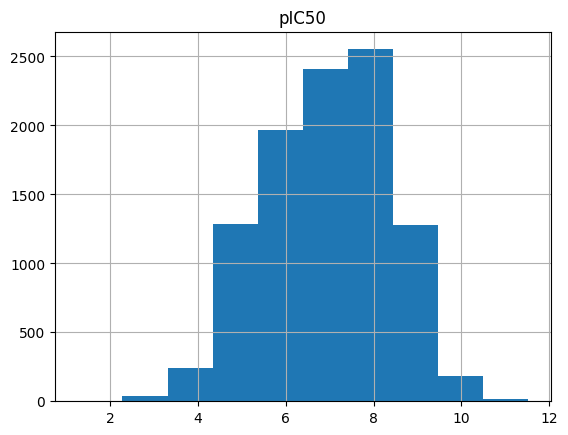

In [43]:
output_df.hist(column="pIC50")

在接下来的步骤中，我们为 `DataFrame` 添加一列 RDKit 分子对象，并查看 pIC50 值最高分子的结构。

In [44]:
# 添加分子列
PandasTools.AddMoleculeColumnToFrame(output_df, smilesCol="smiles")

In [45]:
# 按 pIC50 排序分子
output_df.sort_values(by="pIC50", ascending=False, inplace=True)

# 重置索引
output_df.reset_index(drop=True, inplace=True)

显示三种最活跃的分子，即 pIC50 值最高的分子。

In [46]:
output_df.drop("smiles", axis=1).head(3)

,molecule_chembl_id,IC50,units,pIC50,ROMol
0,CHEMBL63786,0.003,nM,11.522879,<rdkit.Chem.rdchem.Mol object at 0x1190015b0>
1,CHEMBL53711,0.006,nM,11.221849,<rdkit.Chem.rdchem.Mol object at 0x118f74d60>
2,CHEMBL35820,0.006,nM,11.221849,<rdkit.Chem.rdchem.Mol object at 0x118f63e60>


In [47]:
# 准备保存数据集：删除 ROMol 列
output_df = output_df.drop("ROMol", axis=1)
print(f"DataFrame shape: {output_df.shape}")

DataFrame shape: (9979, 5)


#### 将输出数据冻结到 ChEMBL 27

这是一个技术步骤：通常，我们会继续使用刚刚创建的数据集（最新数据集）。

然而，在 TeachOpenCADD 平台上，我们倾向于将数据集冻结到某个 ChEMBL 版本（即 [ChEMBL 27](http://doi.org/10.6019/CHEMBL.database.27)），以便本教程和我们的 CADD 管道中下游的其他教程在未来不会发生变化（有助于我们维护这些教程）。

<div class="alert alert-block alert-info">

<b>注意：</b>如果您希望在本 notebook 中使用最新数据集，或者想将其用于其他靶标，请注释下面的单元格。

</div>

In [48]:
# 禁用此单元格以解冻数据集
output_df = pd.read_csv(
    DATA / "EGFR_compounds_ea055ef.csv", index_col=0, float_precision="round_trip"
)
output_df.head()

,molecule_chembl_id,IC50,units,smiles,pIC50
0,CHEMBL63786,0.003,nM,Brc1cccc(Nc2ncnc3cc4ccccc4cc23)c1,11.522879
1,CHEMBL35820,0.006,nM,CCOc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCC,11.221849
2,CHEMBL53711,0.006,nM,CN(C)c1cc2c(Nc3cccc(Br)c3)ncnc2cn1,11.221849
3,CHEMBL66031,0.008,nM,Brc1cccc(Nc2ncnc3cc4[nH]cnc4cc23)c1,11.096910
4,CHEMBL53753,0.008,nM,CNc1cc2c(Nc3cccc(Br)c3)ncnc2cn1,11.096910


In [49]:
print(f"DataFrame shape: {output_df.shape}")
# NBVAL_CHECK_OUTPUT

DataFrame shape: (5568, 5)


#### 将输出数据写入文件

我们希望在后续教程中使用这个生物活性-化合物数据集，因此将数据保存为 `csv` 文件。
注意，在保存数据时最好删除分子列（该列仅包含分子的图像）。

In [50]:
output_df.to_csv(DATA / "EGFR_compounds.csv")
output_df.head()

,molecule_chembl_id,IC50,units,smiles,pIC50
0,CHEMBL63786,0.003,nM,Brc1cccc(Nc2ncnc3cc4ccccc4cc23)c1,11.522879
1,CHEMBL35820,0.006,nM,CCOc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCC,11.221849
2,CHEMBL53711,0.006,nM,CN(C)c1cc2c(Nc3cccc(Br)c3)ncnc2cn1,11.221849
3,CHEMBL66031,0.008,nM,Brc1cccc(Nc2ncnc3cc4[nH]cnc4cc23)c1,11.096910
4,CHEMBL53753,0.008,nM,CNc1cc2c(Nc3cccc(Br)c3)ncnc2cn1,11.096910


In [51]:
print(f"DataFrame shape: {output_df.shape}")
# NBVAL_CHECK_OUTPUT

DataFrame shape: (5568, 5)


## 讨论

在本教程中，我们从 ChEMBL 数据库中收集了感兴趣靶标的生物活性数据。
我们对数据集进行了筛选，使其仅包含具有 IC50 生物活性测量值的分子。

请注意，ChEMBL 数据来自各种来源。化合物数据是由世界各地的不同实验室、不同人生成的。因此，我们必须谨慎对待使用此数据集所做的预测。在解释结果和确定对预测有多少信心时，始终需要考虑数据的来源以及数据生产实验的一致性。

在接下来的教程中，我们将通过 Lipinski 的"五规则"和不想要的子结构来筛选我们获取的数据。另一个重要的步骤是*清洗*分子数据。虽然我们的教程中（尚未）展示这一点，我们推荐参考 [Standardiser 库](https://github.com/flatkinson/standardiser) 或 [MolVS](https://molvs.readthedocs.io/en/latest/) 作为执行此任务的有用工具。

## 课后思考

* 在本教程中，我们从 ChEMBL 下载了分子和生物活性数据。ChEMBL 数据库还有什么其他用途？
* IC50 和 EC50 有什么区别？
* 从 ChEMBL 提取的数据可以用来做什么？